In [21]:
import yfinance as yf, matplotlib.pyplot as plt, pandas as pd, os, numpy as np

In [22]:
stocks = ["GC=F", "EURUSD=X", "AUDUSD=X", "GBPUSD=X", "USDJPY=X", "^TNX"]

intervals_config = {
    '1m': '7d',    # Max 7 days for 1 minute data
    '5m': '60d',   # Max 60 days for 5 minute data
    '15m': '60d',  # Max 60 days for 15 minute data
    '1h': '730d',  # Max 2 years for 1 hour data
    '1d': 'max'    # Max history for daily data
}

forward_windows = {'1m': 30, '5m': 48, '15m': 32, '1h': 24, '1d': 20}

In [31]:
vix_df = yf.download("^VIX", period="max", progress=False)
if isinstance(vix_df.columns, pd.MultiIndex):
    vix_df.columns = vix_df.columns.get_level_values(0)
vix_series = vix_df['Close'].rename("VIX")

def apply_triple_barrier(df, forward_window, profit_factor, stop_factor):
    closes = df['Close'].values
    highs = df['High'].values
    lows = df['Low'].values
    atrs = df['ATR_pct'].values
    n = len(df)
    signals = np.ones(n)

    profit_targets = closes * (1 + profit_factor * atrs)
    stop_losses = closes * (1 - stop_factor * atrs)

    for i in range(n - forward_window):
        future_highs = highs[i+1 : i+1+forward_window]
        future_lows = lows[i+1 : i+1+forward_window]

        buy_hit = np.argmax(future_highs >= profit_targets[i])
        sell_hit = np.argmax(future_lows <= stop_losses[i])

        buy_triggered = future_highs[buy_hit] >= profit_targets[i]
        sell_triggered = future_lows[sell_hit] <= stop_losses[i]

        if buy_triggered and sell_triggered:
            signals[i] = 2 if buy_hit <= sell_hit else 0
        elif buy_triggered:
            signals[i] = 2
        elif sell_triggered:
            signals[i] = 0

    return signals

def compute_indicators_and_pct(ticker, df, vix_series, interval):
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    df.index.name = None 

    # --- Keep Raw Target for the "Trend Line" ---
    # We save this before doing any log transforms
    df['Target_Close'] = df['Close']

    df['HL_Spread'] = (df['High'] - df['Low']) / df['Close']
    
    # Technical Indicators
    df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()
    df['EMA_Dist'] = (df['Close'] - df['EMA_20']) / df['EMA_20']
    
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI'] = (100 - (100 / (1 + rs))) / 100

    # stochastic oscillator
    low_14 = df['Low'].rolling(window=14).min()
    high_14 = df['High'].rolling(window=14).max()
    
    # %K line (Current close relative to the 14-period range)
    # This natively scales between 0.0 and 1.0!
    df['Stoch_K'] = (df['Close'] - low_14) / (high_14 - low_14)
    
    # %D line (3-period moving average of %K)
    df['Stoch_D'] = df['Stoch_K'].rolling(window=3).mean()
    
    # Merge VIX
    df['Date_Join'] = df.index.date
    vix_temp = vix_series.copy()
    vix_temp.index = vix_temp.index.date
    df = df.join(vix_temp, on='Date_Join')
    df['VIX'] = df['VIX'].ffill()
    df.drop(columns=['Date_Join'], inplace=True)
    
    prev_close = df['Close'].shift(1)
    
    # MACD, ROC, Bollinger Bands
    df['MACD'] = df['Close'].ewm(span=12).mean() - df['Close'].ewm(span=26).mean()
    df['MACD_Signal'] = df['MACD'].ewm(span=9).mean()
    df['MACD_Hist'] = df['MACD'] - df['MACD_Signal']
    df['ROC'] = df['Close'].pct_change(periods=10)
    df['BB_Middle'] = df['Close'].rolling(20).mean()
    df['BB_Std'] = df['Close'].rolling(20).std()
    df['BB_Upper'] = df['BB_Middle'] + (2 * df['BB_Std'])
    df['BB_Lower'] = df['BB_Middle'] - (2 * df['BB_Std'])
    df['BB_Position'] = (df['Close'] - df['BB_Lower']) / (df['BB_Upper'] - df['BB_Lower'])
    df['BB_Width'] = df['BB_Upper'] - df['BB_Lower']

    # --- FEATURE ENGINEERING (Log Returns for Input) ---
    df_final = pd.DataFrame(index=df.index)
    df_final['Open'] = np.log(df['Open'] / prev_close)
    df_final['High'] = np.log(df['High'] / prev_close)
    df_final['Low'] = np.log(df['Low'] / prev_close)
    df_final['Close'] = np.log(df['Close'] / prev_close)

    # --- CALCULATE ATR (Average True Range) ---
    # 1. True Range components
    high_low = df['High'] - df['Low']
    high_prev_close = np.abs(df['High'] - df['Close'].shift(1))
    low_prev_close = np.abs(df['Low'] - df['Close'].shift(1))
    
    # 2. Find the maximum of the three for each row
    true_range = pd.concat([high_low, high_prev_close, low_prev_close], axis=1).max(axis=1)
    
    # 3. Calculate the 14-period Average True Range
    df['ATR'] = true_range.rolling(window=14).mean()
    
    # 4. Convert to Percentage (so it matches your Log Returns)
    df['ATR_pct'] = df['ATR'] / df['Close']   
    
    #macro trend distance
    df['EMA_50'] = df['Close'].ewm(span=50, adjust=False).mean()
    df['Trend_Dist_50'] = (df['Close'] - df['EMA_50']) / df['EMA_50']
    
    # 2. Macro Trend
    df['EMA_200'] = df['Close'].ewm(span=200, adjust=False).mean()
    df['Trend_Dist_200'] = (df['Close'] - df['EMA_200']) / df['EMA_200']
    
    # 3. The Reversal Indicator (How far apart are the two EMAs?)
    df['EMA_Spread'] = (df['EMA_50'] - df['EMA_200']) / df['EMA_200']
    
    # cyclical time features
    temp_index = pd.to_datetime(df.index)
    hour = temp_index.hour

    df['Hour_Sin'] = np.sin(2 * np.pi * hour / 24.0)
    df['Hour_Cos'] = np.cos(2 * np.pi * hour / 24.0)

    # asian settings 12am to 9am
    df['is_asia'] = ((hour >= 0) & (hour < 9)).astype(int)

    # london settings 8am to 4pm
    df['is_london'] = ((hour >= 8) & (hour < 16)).astype(int)

    # nyc settings 1pm to 10pm
    df['is_new_york'] = ((hour >= 13) & (hour < 22)).astype(int)

    # #vwap
    typical_price = (df['High'] + df['Low'] + df['Close']) / 3
    if 'Volume' in df.columns and df['Volume'].sum() > 0:
        # Add a tiny epsilon (1e-8) to the denominator to mathematically prevent division by zero
        vol_sum = df['Volume'].rolling(window=24).sum()
        df['Rolling_VWAP'] = (typical_price * df['Volume']).rolling(window=24).sum() / (vol_sum + 1e-8)
    else:
        # FALLBACK: If there is no volume (like in Forex), we just use the moving average of the typical price.
        # This acts identically to VWAP for the neural network's purposes.
        df['Rolling_VWAP'] = typical_price.rolling(window=24).mean()
    df['VWAP_Dist'] = (df['Close'] - df['Rolling_VWAP']) / df['Rolling_VWAP']


    # --- ADD TARGETS & REMAINING FEATURES ---
    df_final['Target_Close'] = df['Target_Close'] # This is the price for the trend line
    df_final['VIX'] = np.log(df['VIX'] / df['VIX'].shift(1).replace(0, np.nan)).fillna(0)
    df_final['RSI'] = df['RSI']
    df_final['EMA_Dist'] = df['EMA_Dist']
    df_final['50TD'] = df['Trend_Dist_50']
    df_final['200TD'] = df['Trend_Dist_200']
    df_final['EMA_Spread'] = df['EMA_Spread']
    df_final['Stoch_K'] = df['Stoch_K']
    df_final['Stoch_D'] = df['Stoch_D']
    df_final['Rolling_WVAP'] = df['Rolling_VWAP']
    df_final['VWAP_Dist'] = df['VWAP_Dist']
    df_final['Volatility'] = df['HL_Spread']
    df_final['Hour_Sin'] = df['Hour_Sin']
    df_final['Hour_Cos'] = df['Hour_Cos']
    df_final['Signal'] = apply_triple_barrier(df, forward_windows[interval], 6.0, 5.7)
    df_final['is_new_york'] = df['is_new_york']
    df_final['is_london'] = df['is_london']
    df_final['is_asia'] = df['is_asia']
    df_final['MACD'] = df['MACD']
    df_final['ROC'] = df['ROC']
    df_final['BB_Position']= df['BB_Position']
    df_final['Ticker'] = ticker
    df_final.replace([np.inf, -np.inf], np.nan, inplace=True)
        
    return df_final.dropna()

In [32]:
# Create a directory for each interval to keep things organized
base_dir = r"C:\Users\supah\OneDrive\Documents\School\Uni Projects\StockPrediction\data"
os.makedirs(base_dir, exist_ok=True)

for interval, period in intervals_config.items():
    print(f"\nProcessing Interval: {interval}...")
    
    # Create sub-folder for intervals (e.g., data/1h/)
    save_dir = os.path.join(base_dir, interval)
    os.makedirs(save_dir, exist_ok=True)
    
    for t in stocks:
        try:
            # 1. Download Data
            raw_df = yf.download(t, interval=interval, period=period, progress=False)
            
            if raw_df.empty:
                continue
                
            # 2. Process Data
            # We handle the VIX merge carefully here
            clean_df = compute_indicators_and_pct(t, raw_df, vix_series, interval)
            
            # 3. Validation: Drop rows ONLY if essential features are missing
            # (Don't drop just because VIX is missing, we can fill it)
            if clean_df['VIX'].isnull().all():
                print(f"  Warning: VIX missing for {t} (filling with 0)")
                clean_df['VIX'] = 0.0
            else:
                # Forward fill VIX gaps caused by minute-level merging
                clean_df['VIX'] = clean_df['VIX'].ffill().bfill()

            # 4. Save INDIVIDUAL CSVs
            # Replace invalid filename chars (like = in AUDCAD=X)
            safe_ticker = t.replace("=", "")
            save_path = os.path.join(save_dir, f"{safe_ticker}.csv")
            
            clean_df.replace([np.inf, -np.inf], np.nan, inplace=True)
            clean_df.dropna(inplace=True)
            clean_df.to_csv(save_path)
            print(f"  Saved {t} -> {len(clean_df)} rows")
                
            df = pd.read_csv(save_path)
            print(df['Signal'].value_counts(normalize=True) * 100)
            #print((df['High'].rolling(20).max() / df['Close'].shift(20) - 1).describe())

        except Exception as e:
            print(f"  Error with {t}: {e}")

print("\nData download complete. Files saved in separate folders.")


Processing Interval: 1m...
  Saved GC=F -> 7520 rows
Signal
1.0    69.308511
0.0    21.356383
2.0     9.335106
Name: proportion, dtype: float64
  Saved EURUSD=X -> 9345 rows
Signal
1.0    36.554307
0.0    33.055110
2.0    30.390583
Name: proportion, dtype: float64
  Saved AUDUSD=X -> 4678 rows
Signal
1.0    34.950834
0.0    34.459171
2.0    30.589996
Name: proportion, dtype: float64
  Saved GBPUSD=X -> 9366 rows
Signal
1.0    35.554132
0.0    33.973948
2.0    30.471920
Name: proportion, dtype: float64
  Saved USDJPY=X -> 9366 rows
Signal
1.0    86.120009
0.0     8.199872
2.0     5.680120
Name: proportion, dtype: float64
  Saved ^TNX -> 2551 rows
Signal
1.0    55.468444
2.0    23.284986
0.0    21.246570
Name: proportion, dtype: float64

Processing Interval: 5m...
  Saved GC=F -> 13526 rows
Signal
1.0    57.149194
0.0    24.634038
2.0    18.216768
Name: proportion, dtype: float64
  Saved EURUSD=X -> 16476 rows
Signal
1.0    41.672736
0.0    32.853848
2.0    25.473416
Name: proportion, d

Text(0.5, 1.0, 'Stock BB Width Over Time')

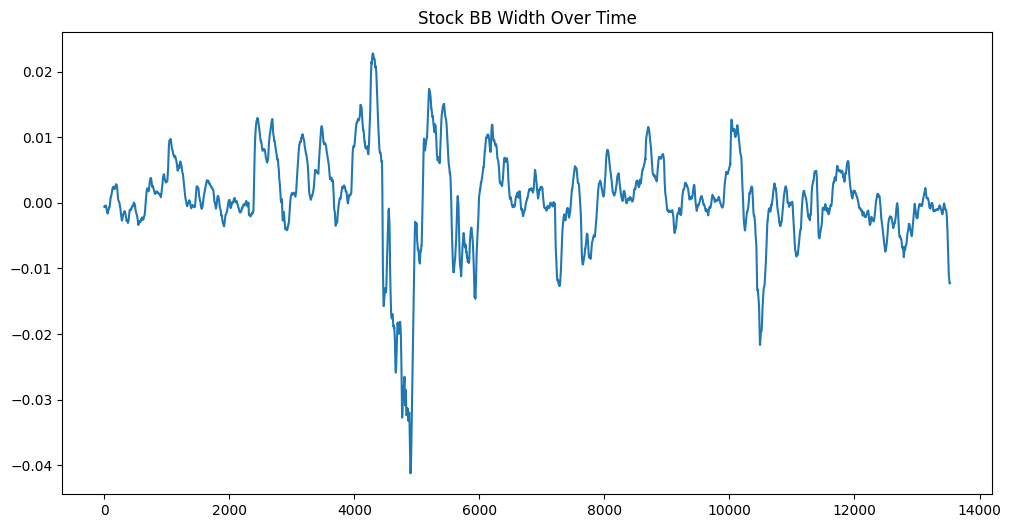

In [25]:
plt.figure(figsize=(12, 6))
df = pd.read_csv(f"C:\\Users\\supah\\OneDrive\\Documents\\School\\Uni Projects\\StockPrediction\\data\\5m\\GCF.csv")
plt.plot(df['EMA_Spread'], label='AUDCADX')
plt.title('Stock BB Width Over Time')

In [26]:
df.sample(5)

,Unnamed: 0,Open,High,Low,Close,Target_Close,VIX,RSI,EMA_Dist,50TD,...,Hour_Sin,Hour_Cos,Signal,is_new_york,is_london,is_asia,MACD,ROC,BB_Position,Ticker
6062,2026-02-06 12:10:00+00:00,-0.000142,0.000325,-0.001587,-0.000508,4917.700195,0.0,0.699149,0.002447,0.004964,...,1.224647e-16,-1.000000e+00,1.0,0,1,0,7.173071,0.001466,0.882434,GC=F
7582,2026-02-16 01:35:00+00:00,0.000178,0.000376,-0.000436,-0.000059,5047.600098,0.0,0.738505,0.001057,0.000820,...,2.588190e-01,9.659258e-01,0.0,0,0,1,0.910834,0.002085,0.855177,GC=F
9876,2026-02-27 10:35:00+00:00,-0.000096,0.000636,-0.000636,0.000501,5190.500000,0.0,0.418744,-0.000424,-0.001075,...,5.000000e-01,-8.660254e-01,2.0,0,1,0,-1.938079,-0.000558,0.275759,GC=F
1507,2026-01-13 17:45:00+00:00,-0.000043,0.000564,-0.000564,-0.000520,4610.399902,0.0,0.386713,-0.001632,-0.001503,...,-9.659258e-01,-2.588190e-01,0.0,1,0,0,-1.388912,-0.002553,0.045194,GC=F
2413,2026-01-20 06:45:00+00:00,0.000000,0.000996,-0.000276,0.000678,4719.700195,0.0,0.658225,0.002994,0.010473,...,1.000000e+00,6.123234e-17,1.0,0,0,1,16.536825,-0.000191,0.753748,GC=F
